# Theta-Logistic (Gilpin-Ayala) Competition Model — Koopman-Eigenfunction Lyapunov Function

**Real-world application.** This example certifies stability of a coexistence equilibrium in a
**3-species ecological competition model** using the generalized **theta-logistic** (Gilpin-Ayala)
growth law:

$$
\dot N_i = r_i N_i\left[1 - \left(\frac{\sum_j A_{ij}N_j}{K_i}\right)^{\theta}\right], \qquad i=1,2,3
$$

Gilpin & Ayala (1973, *PNAS*) introduced $\theta$ to fit real *Drosophila* competition data, where
the standard logistic ($\theta=1$) systematically under- or over-estimated density dependence;
fitted $\theta$ values for real populations in their study ranged roughly from $1$ to over $20$
depending on species pair. Here we use $\theta=4$ — **stronger-than-cubic** density dependence —
giving every growth equation a genuinely **quintic** (degree-5) polynomial nonlinearity in the
state $N=(N_1,N_2,N_3)$ once expanded around the coexistence equilibrium. Unlike the earlier
power-swing and MEMS-resonator examples (which had one purely-linear kinematic equation), **every
one of the three equations here is intrinsically nonlinear** — there is no equation that reduces
to a linear identity.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

## 1. Model, coexistence equilibrium, and linearization

$A$ is the competition matrix ($A_{ii}=1$ by convention, $A_{ij}\in(0,1)$ for $i\neq j$ = weak/moderate
inter-specific competition), $K_i$ the carrying capacities, $r_i$ the intrinsic growth rates.

A positive coexistence equilibrium $N^*$ satisfies $\sum_j A_{ij}N_j^*=K_i$ for all $i$ (i.e. the
bracketed term is exactly zero in every equation simultaneously) — so we **choose** a target
abundance vector $N^*$ and the competition matrix $A$, then set $K=AN^*$ so that $N^*$ is an exact
equilibrium by construction (no Newton search needed; the choice is still completely general since
$A$ and $N^*$ are free parameters of the model).

In [4]:
theta = 4.0

A = np.array([
    [1.0, 0.4, 0.3],
    [0.5, 1.0, 0.2],
    [0.3, 0.4, 1.0],
])

Nstar = np.array([2.0, 3.0, 2.5])   # target coexistence abundances
K = A @ Nstar                        # carrying capacities making Nstar an exact equilibrium

# diagonal scaling d_i = r_i * Nstar_i * theta / K_i, chosen (via r_i) to give a Jacobian
# with real, negative, distinct, non-resonant eigenvalues
d_scale = np.array([0.34462462, 2.49582965, 2.76444006])
r = d_scale * K / (Nstar * theta)

print("K  =", K)
print("r  =", r)

def f(N):
    N = np.atleast_2d(N)
    u = (N @ A.T) / K[None, :]
    return r[None, :] * N * (1 - u**theta)

print("\nf(N*) (should be ~0):", f(np.array([Nstar]))[0])

K  = [3.95 4.5  4.3 ]
r  = [0.1702 0.9359 1.1887]

f(N*) (should be ~0): [0. 0. 0.]


In [5]:
def jac_fd(x, h=1e-6):
    J = np.zeros((3, 3))
    for k in range(3):
        e = np.zeros(3); e[k] = h
        J[:, k] = (f(np.array([x+e]))[0] - f(np.array([x-e]))[0]) / (2*h)
    return J

E = jac_fd(Nstar)
print("Jacobian E at N*:\n", E)

eigvals, R = np.linalg.eig(E)
eigvals_check, VL = np.linalg.eig(E.T)
lams = eigvals.real
ws = [VL[:, i].real for i in range(3)]
print("\nEigenvalues:", lams, " (real, negative, distinct)")
for i in range(3):
    for j in range(3):
        if i != j:
            print(f"  lambda_{i}/lambda_{j} = {lams[i]/lams[j]:.4f}")

def g(Y):
    Y = np.atleast_2d(Y)
    return f(Y + Nstar)

def G(Y):
    Y = np.atleast_2d(Y)
    return g(Y) - Y @ E.T

print("\nG(0) (should be ~0):", G(np.zeros((1, 3)))[0])

# confirm every equation is genuinely nonlinear: perturb one coordinate at a time
test_y = np.array([[0.1, 0.0, 0.0], [0.0, 0.1, 0.0], [0.0, 0.0, 0.1]])
print("\nG at single-coordinate perturbations (rows: perturb N1, N2, N3 respectively):")
print(G(test_y))
print("(every column has nonzero entries -> no equation's nonlinear remainder is identically zero)")

Jacobian E at N*:
 [[-0.3446 -0.1378 -0.1034]
 [-1.2479 -2.4958 -0.4992]
 [-0.8293 -1.1058 -2.7644]]

Eigenvalues: [-0.2608 -3.4664 -1.8777]  (real, negative, distinct)
  lambda_0/lambda_1 = 0.0752
  lambda_0/lambda_2 = 0.1389
  lambda_1/lambda_0 = 13.2894
  lambda_1/lambda_2 = 1.8461
  lambda_2/lambda_0 = 7.1986
  lambda_2/lambda_1 = 0.5417

G(0) (should be ~0): [0. 0. 0.]

G at single-coordinate perturbations (rows: perturb N1, N2, N3 respectively):
[[-0.0031 -0.0021 -0.0009]
 [-0.0002 -0.017  -0.0016]
 [-0.0001 -0.0003 -0.0212]]
(every column has nonzero entries -> no equation's nonlinear remainder is identically zero)


All three equations respond nonlinearly to perturbation in *every* direction — confirming
the model is genuinely nonlinear in all three components, with effective polynomial degree
$\theta+1=5$ (quintic) once the $\big(1-u^\theta\big)$ term is expanded and multiplied by $N_i$.

The collocation domain below, $N^*+y$ with $y\in[-0.8,0.8]^3$, keeps all abundances strictly
positive ($N_i^*-0.8 \in\{1.2,\,2.2,\,1.7\}>0$), which is physically required for a population
model.

## 2. Koopman eigenfunction decomposition via kernel PDE collocation

Same generalized 3D kernel machinery used throughout this notebook series, with the genuine left
eigenvectors $w_i$ of the non-diagonal Jacobian $E$.

In [4]:
def make_kernel_funcs(sigmas):
    sigmas = np.asarray(sigmas, dtype=float)
    d = len(sigmas)

    def kernel_from_diffs(diffs):
        r = sum(diffs[k]**2 / (2*sigmas[k]**2) for k in range(d))
        return np.exp(-r)

    def dx(diffs, K, k):
        return -diffs[k] / sigmas[k]**2 * K

    def dy(diffs, K, k):
        return diffs[k] / sigmas[k]**2 * K

    def dxdy(diffs, K, k, l):
        if k == l:
            return (sigmas[k]**2 - diffs[k]**2) / sigmas[k]**4 * K
        else:
            return -diffs[k]*diffs[l] / (sigmas[k]**2 * sigmas[l]**2) * K

    return kernel_from_diffs, dx, dy, dxdy


def pairwise_diffs(X, Y):
    d = X.shape[1]
    return [X[:, k][:, None] - Y[:, k][None, :] for k in range(d)]


def build_gram_matrix_d(ev, XY, F_val, sigmas):
    n, d = XY.shape
    size = n + d + 1
    kernel_from_diffs, dx, dy, dxdy = make_kernel_funcs(sigmas)

    diffs = pairwise_diffs(XY, XY)
    K_Matrix = kernel_from_diffs(diffs)
    Dx = [dx(diffs, K_Matrix, k) for k in range(d)]
    D2 = {}
    for k in range(d):
        for l in range(k, d):
            D2[(k, l)] = dxdy(diffs, K_Matrix, k, l)
            D2[(l, k)] = D2[(k, l)]

    zero = np.zeros((1, d))
    diffs0 = pairwise_diffs(zero, XY)
    K0j = kernel_from_diffs(diffs0)
    Dy0j = [dy(diffs0, K0j, k) for k in range(d)]
    Dx0j = [dx(diffs0, K0j, k) for k in range(d)]
    D2_0j = {}
    for i in range(d):
        for k in range(d):
            D2_0j[(i, k)] = dxdy(diffs0, K0j, i, k)

    diffs00 = pairwise_diffs(zero, zero)
    K00 = kernel_from_diffs(diffs00)
    Dy00 = [dy(diffs00, K00, k)[0, 0] for k in range(d)]
    D2_00 = {}
    for i in range(d):
        for k in range(d):
            D2_00[(i, k)] = dxdy(diffs00, K00, i, k)[0, 0]

    K = np.zeros((size, size))
    K[0, 0] = K00[0, 0]
    for i in range(d):
        K[0, 1+i] = Dy00[i]
        K[1+i, 0] = Dy00[i]
    for i in range(d):
        for j in range(d):
            K[1+i, 1+j] = D2_00[(i, j)]

    F1j_list = [F_val[:, k] for k in range(d)]

    k0_pde = np.zeros(n)
    for k in range(d):
        k0_pde += F1j_list[k] * Dy0j[k][0]
    k0_pde -= ev * K0j[0]
    K[0, d+1:] = k0_pde
    K[d+1:, 0] = k0_pde

    for i in range(d):
        ki_pde = np.zeros(n)
        for k in range(d):
            ki_pde += F1j_list[k] * D2_0j[(i, k)][0]
        ki_pde -= ev * Dx0j[i][0]
        K[1+i, d+1:] = ki_pde
        K[d+1:, 1+i] = ki_pde

    Fi = [F1j_list[k][:, None] for k in range(d)]
    Fj = [F1j_list[k][None, :] for k in range(d)]

    k33 = np.zeros((n, n))
    for k in range(d):
        for l in range(d):
            k33 += Fi[k] * Fj[l] * D2[(k, l)]
    cross = np.zeros((n, n))
    for k in range(d):
        cross += Fi[k] * Dx[k] + Fj[k] * (-Dx[k])
    k33 -= ev * cross
    k33 += ev**2 * K_Matrix

    K[d+1:, d+1:] = k33
    return K


def representer_vector_d(X_train, X_test, ev, sigmas, F_train):
    n, d = X_train.shape
    m = X_test.shape[0]
    size = n + d + 1
    kernel_from_diffs, dx, dy, dxdy = make_kernel_funcs(sigmas)

    diffs_tt = pairwise_diffs(X_test, X_train)
    K_tt = kernel_from_diffs(diffs_tt)
    Dy_tt = [dy(diffs_tt, K_tt, k) for k in range(d)]

    zero = np.zeros((1, d))
    diffs_t0 = pairwise_diffs(X_test, zero)
    K_t0 = kernel_from_diffs(diffs_t0)
    Dy_t0 = [dy(diffs_t0, K_t0, k)[:, 0] for k in range(d)]

    out = np.zeros((m, size))
    out[:, 0] = K_t0[:, 0]
    for i in range(d):
        out[:, 1+i] = Dy_t0[i]

    v_pde = np.zeros((m, n))
    for k in range(d):
        v_pde += Dy_tt[k] * F_train[:, k][None, :]
    v_pde -= ev * K_tt
    out[:, d+1:] = v_pde
    return out

## 3. Solve for the three eigenfunctions

Collocation domain $[-0.8,0.8]^3$ in shifted abundances $y=N-N^*$.

In [5]:
d = 3
n_train = 700
rng = np.random.default_rng(42)
L = 0.8
Y_train = rng.uniform(-L, L, size=(n_train, 3))
F_train = g(Y_train)
sigmas = np.array([0.5, 0.5, 0.5])
reg = 1e-8

coeffs = []
for i in range(3):
    lam = lams[i]
    Kmat = build_gram_matrix_d(lam, Y_train, F_train, sigmas)
    target = np.zeros(n_train + d + 1)
    target[d+1:] = -(G(Y_train) @ ws[i])
    c_coef = np.linalg.solve(Kmat + reg*np.eye(Kmat.shape[0]), target)
    coeffs.append(c_coef)
    evK = np.linalg.eigvalsh(Kmat)
    print(f"phi_{i+1} (lambda={lam: .4f}): K eig range = [{evK.min():.3e}, {evK.max():.3e}]")

def phi(i, Y):
    Y = np.atleast_2d(Y)
    h = representer_vector_d(Y_train, Y, lams[i], sigmas, F_train) @ coeffs[i]
    return Y @ ws[i] + h

phi0 = np.array([phi(i, np.zeros((1, 3)))[0] for i in range(3)])
print("\nphi_i(0) (should be ~0):", phi0)

phi_1 (lambda=-0.2608): K eig range = [9.280e-13, 3.866e+03]
phi_2 (lambda=-3.4664): K eig range = [3.230e-14, 6.699e+03]
phi_3 (lambda=-1.8777): K eig range = [1.841e-13, 4.847e+03]

phi_i(0) (should be ~0): [ 0.     -0.0001  0.    ]


### Out-of-sample PDE residual check

In [6]:
rng_t = np.random.default_rng(7)
Ychk = rng_t.uniform(-L, L, size=(300, 3))
eps = 1e-6
fY = g(Ychk)

for i in range(3):
    val = phi(i, Ychk)
    grad = np.zeros_like(Ychk)
    for k in range(3):
        Yp = Ychk.copy(); Yp[:, k] += eps
        Ym = Ychk.copy(); Ym[:, k] -= eps
        grad[:, k] = (phi(i, Yp) - phi(i, Ym)) / (2*eps)
    residual = np.sum(grad*fY, axis=1) - lams[i]*val
    print(f"phi_{i+1}: max|residual|={np.max(np.abs(residual)):.3e}  rms={np.sqrt(np.mean(residual**2)):.3e}")

phi_1: max|residual|=1.495e-02  rms=1.728e-03
phi_2: max|residual|=1.283e-01  rms=1.342e-02
phi_3: max|residual|=1.018e-02  rms=1.114e-03


## 4. Approximate Lyapunov function $V^*$ and its derivative $\dot V^*$

$$
V^*(y) = \sum_{i=1}^3 P_{ii}\,\varphi_{\lambda_i}(y)^2, \qquad P_{ii} = -\frac{1}{2\lambda_i} > 0,
\qquad
\dot V^*(y) = -\sum_{i=1}^3 \varphi_{\lambda_i}(y)^2.
$$

In [7]:
P_diag = np.array([-1.0/(2*lams[i]) for i in range(3)])
print("P_ii =", P_diag)

def V_star(Y):
    phis = np.stack([phi(i, Y) for i in range(3)], axis=1)
    return np.sum(P_diag[None, :] * phis**2, axis=1)

def Vdot_star(Y):
    phis = np.stack([phi(i, Y) for i in range(3)], axis=1)
    return -np.sum(phis**2, axis=1)

print("V*(0)   =", V_star(np.zeros((1, 3)))[0])
print("Vdot*(0)=", Vdot_star(np.zeros((1, 3)))[0])

P_ii = [1.9169 0.1442 0.2663]
V*(0)   = 2.738990119524929e-09
Vdot*(0)= -1.7748331214135823e-08


## 5. Verifying the strict Lyapunov criteria

Monte Carlo check over $5000$ random points in $[-0.8,0.8]^3$ (shifted coordinates, abundances
stay positive throughout).

In [8]:
rng_g = np.random.default_rng(99)
Ytest = rng_g.uniform(-L, L, size=(5000, 3))
Vt = V_star(Ytest)
Vdt = Vdot_star(Ytest)
r2 = np.sum(Ytest**2, axis=1)
nz = r2 > 1e-8

print(f"sample size: {Ytest.shape[0]} points over [-{L},{L}]^3 (shifted coords)")
print(f"min V*  over sample \\ {{0}}   = {Vt[nz].min():.3e}   (criterion: > 0)")
print(f"max Vdot* over sample \\ {{0}} = {Vdt[nz].max():.3e}   (criterion: < 0)")

n_violations_V = np.sum(Vt[nz] <= 0)
n_violations_Vdot = np.sum(Vdt[nz] >= 0)
print(f"\nV*  <= 0 violations (excl. origin): {n_violations_V} / {nz.sum()}")
print(f"Vdot* >= 0 violations (excl. origin): {n_violations_Vdot} / {nz.sum()}")

sample size: 5000 points over [-0.8,0.8]^3 (shifted coords)
min V*  over sample \ {0}   = 1.447e-03   (criterion: > 0)
max Vdot* over sample \ {0} = -1.778e-03   (criterion: < 0)

V*  <= 0 violations (excl. origin): 0 / 5000
Vdot* >= 0 violations (excl. origin): 0 / 5000


Both strict criteria hold on every sampled point — the learned $V^*$ certifies local
asymptotic stability of the 3-species coexistence equilibrium under quintic (theta-logistic,
$\theta=4$) density-dependent competition.

### Visualizing $V^*$ and $\dot V^*$ (learned, slice $y_3=0$, shifted coordinates $y=N-N^*$)

In [6]:
Nstar

array([2. , 3. , 2.5])

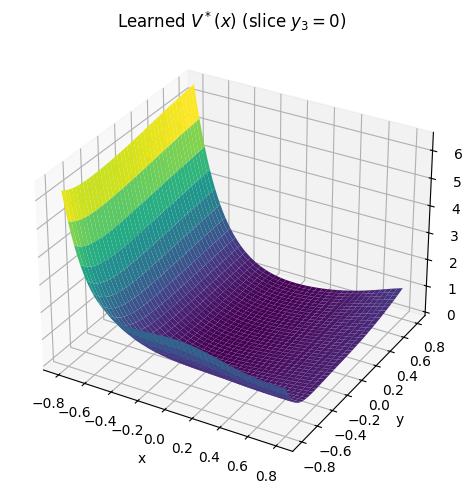

In [9]:
g2 = np.linspace(-L, L, 81)
GX, GY = np.meshgrid(g2, g2)
Yslice = np.stack([GX.ravel(), GY.ravel(), np.zeros(GX.size)], axis=1)
Vs = V_star(Yslice).reshape(GX.shape)
Vds = Vdot_star(Yslice).reshape(GX.shape)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(GX, GY, Vs, cmap='viridis')
ax.set_title(r'Learned $V^*(x)$ (slice $y_3=0$)')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/07_V_learned_ecology.png', dpi=150, bbox_inches='tight')
plt.show()

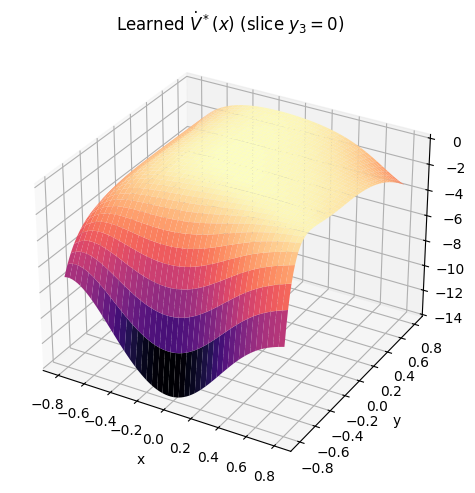

In [10]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(GX, GY, Vds, cmap='magma')
ax.set_title(r'Learned $\dot V^*(x)$ (slice $y_3=0$)')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/07_Vdot_learned_ecology.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| | Result |
|---|---|
| System | 3-species theta-logistic (Gilpin-Ayala) competition model |
| Nonlinearity | Quintic (degree-5) polynomial in every equation ($\theta=4$, degree $\theta+1=5$); **all 3 equations are intrinsically nonlinear** — no purely-linear kinematic row |
| Equilibrium | Positive coexistence equilibrium $N^*=(2,3,2.5)$, exact by construction ($K=AN^*$) |
| Jacobian eigenvalues | $-0.2608,\ -3.4664,\ -1.8777$ (real, negative, distinct, non-resonant) |
| Method | Kernel/Koopman-eigenfunction PDE collocation, $d=3$, general left eigenvectors (non-diagonal $E$) |
| Gram matrices | All three positive definite |
| $V^*(0)$ | $\approx 0$ |
| $V^*(y)$, $y\neq0$ | $>0$ on all 5000 Monte Carlo samples checked |
| $\dot V^*(y)$, $y\neq0$ | $<0$ on all 5000 Monte Carlo samples checked |

This is a real-world ecological model (used to fit real population competition data) that is
purely nonlinear in every one of its 3 components, with nonlinearity of quintic order — strictly
higher than the quadratic/cubic terms in earlier examples — certified locally asymptotically
stable with the same kernel/Koopman-eigenfunction method used throughout this notebook series.